In [ ]:
from __future__ import annotations
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

def periodic_dx(x_grid: np.ndarray, x0: float, Lx: float) -> np.ndarray:
    
    '''
    Purpose
    --------
    Compute the shortest periodic distance Δx = x - x0 on a domain [0, Lx).

    Inputs
    ------
    x_grid : ndarray | Array of x positions.
        x0 : float | Reference x position.
        Lx : float | Periodic domain length.

    Outputs
    --------
    dx : ndarray | Signed periodic distance with the same shape as x_grid, wrapped into [-Lx/2, +Lx/2).

    Author(s)
    ---------
    Julio M. Morales, Jan. 21st, 2026.
    '''
    
    # Compute periodic distance
    dx = x_grid - x0
    
    return (dx + 0.5 * Lx) % Lx - 0.5 * Lx

def blob(xg: np.ndarray, zg: np.ndarray, x0: float, z0: float, sx: float, sz: float, Lx: float) -> np.ndarray:
    
    '''
    Purpose
    --------
    Construct a 2D Gaussian blob centered at (x0, z0) that is periodic in x.

    Inputs
    ------
    xg : ndarray | 2D meshgrid of x coordinates with shape (nz, nx).
    zg : ndarray | 2D meshgrid of z coordinates with shape (nz, nx).
    x0 : float | Blob center x-position.
    z0 : float | Blob center z-position.
    sx : float | Gaussian width in x (standard deviation).
    sz : float | Gaussian width in z (standard deviation).
    Lx : float | Periodic domain length in x.

    Outputs
    --------
    G : ndarray | Gaussian weight field G(x,z) with shape (nz, nx), maximum ~ 1 at the center.

    Author(s)
    ---------
    Julio M. Morales, Jan. 21st, 2026.
    '''
    
    # Compute periodic distance in x
    dxp = periodic_dx(xg, x0, Lx)
    
    return np.exp(-(dxp**2) / (2.0 * sx**2)) * np.exp(-((zg - z0) ** 2) / (2.0 * sz**2))


def rho_bg(z: np.ndarray, z_bot: float, z_top: float, rho_top: float, rho_bot: float) -> np.ndarray:
    
    '''
    Purpose
    --------
    Construct a linearly stratified background density profile ρ_bg(z) such that
    the bottom of the domain is denser than the top (rho_bot > rho_top).

    Inputs
    ------
          z : ndarray | 1D vertical coordinate array (increasing upward).
      z_bot : float | Lower vertical boundary of the domain.
      z_top : float | Upper vertical boundary of the domain.
    rho_top : float | Background density at z = z_top.
    rho_bot : float | Background density at z = z_bot.

    Outputs
    --------
    rho0 : ndarray | Background density profile ρ_bg(z), with the same shape as z.

    Author(s)
    ---------
    Julio M. Morales, Jan. 21st, 2026.
    '''
    
    # Linear interpolation
    alpha = (rho_bot - rho_top) / (z_top - z_bot)
    
    return rho_top + alpha * (z_top - z)

def deta_dt(w: float) -> float:
    
    '''
    Purpose
    --------
    Evaluate the time derivative of parcel displacement η(t), where η(t) = z_p(t) - z_eq.

    Governing equation:
        dη/dt = w

    Inputs
    ------
    w : float | Parcel vertical velocity.

    Outputs
    --------
    deta : float | Time derivative of parcel displacement, dη/dt.

    Author(s)
    ---------
    Julio M. Morales, Jan. 21st, 2026.
    '''
    
    return w

def dw_dt(b: float) -> float:
    
    '''
    Purpose
    --------
    Evaluate the time derivative of parcel vertical velocity w(t).

    Governing equation:
        dw/dt = b

    Inputs
    ------
    b : float | Parcel buoyancy.

    Outputs
    --------
    dw : float | Time derivative of parcel vertical velocity, dw/dt.

    Author(s)
    ---------
    Julio M. Morales, Jan. 21st, 2026.
    '''
    
    return b

def db_dt(w: float, N2: float) -> float:
    
    '''
    Purpose
    --------
    Evaluate the time derivative of parcel buoyancy b(t) for constant stratification.

    Governing equation:
        db/dt = -N^2 w

    Inputs
    ------
     w : float | Parcel vertical velocity.
    N2 : float | Brunt–Väisälä frequency squared (constant).

    Outputs
    --------
    db : float | Time derivative of parcel buoyancy, db/dt.

    Author(s)
    ---------
    Julio M. Morales, Jan. 21st, 2026.
    '''
    
    return -N2 * w

def rhs(eta: float, w: float, b: float, N2: float) -> tuple[float, float, float]:
    
    '''
    Purpose
    --------
    Return the right-hand-side (RHS) time derivatives for the full parcel ODE system,
    expressed as (dη/dt, dw/dt, db/dt).

    Inputs
    ------
    eta : float | Parcel displacement η(t) = z_p(t) - z_eq.
      w : float | Parcel vertical velocity.
      b : float | Parcel buoyancy.
     N2 : float | Brunt–Väisälä frequency squared (constant).

    Outputs
    --------
    deta : float | Time derivative dη/dt.
      dw : float | Time derivative dw/dt.
      db : float | Time derivative db/dt.

    Author(s)
    ---------
    Julio M. Morales, Jan. 21st, 2026.
    '''
    
    # Return the right-hand-side (RHS) time derivatives for the full parcel ODE system
    return deta_dt(w), dw_dt(b), db_dt(w, N2)

def rk4(eta: float, w: float, b: float, dt: float, N2: float) -> tuple[float, float, float]:
    
    '''
    Purpose
    --------
    Advance the parcel ODE system one timestep using a classical 4th-order Runge–Kutta (RK4) scheme.

    Inputs
    ------
    eta : float | Parcel displacement at the current timestep.
      w : float | Parcel vertical velocity at the current timestep.
      b : float | Parcel buoyancy at the current timestep.
     dt : float | Timestep size.
     N2 : float | Brunt–Väisälä frequency squared (constant).

    Outputs
    --------
    eta_new : float | Updated parcel displacement after one RK4 timestep.
      w_new : float | Updated parcel vertical velocity after one RK4 timestep.
      b_new : float | Updated parcel buoyancy after one RK4 timestep.

    Author(s)
    ---------
    Julio M. Morales, Jan. 21st, 2026.
    '''
    
    # Classical RK4 scheme
    k1_eta, k1_w, k1_b = rhs(eta, w, b, N2)
    
    # Compute intermediate steps
    eta2 = eta + 0.5 * dt * k1_eta
    w2 = w + 0.5 * dt * k1_w
    b2 = b + 0.5 * dt * k1_b
    
    # Compute k2
    k2_eta, k2_w, k2_b = rhs(eta2, w2, b2, N2)
    
    # Compute k3
    eta3 = eta + 0.5 * dt * k2_eta
    w3 = w + 0.5 * dt * k2_w
    b3 = b + 0.5 * dt * k2_b
    
    # Compute k3
    k3_eta, k3_w, k3_b = rhs(eta3, w3, b3, N2)

    # Compute k4
    eta4 = eta + dt * k3_eta
    w4 = w + dt * k3_w
    b4 = b + dt * k3_b
    
    # Compute k4
    k4_eta, k4_w, k4_b = rhs(eta4, w4, b4, N2)

    # Combine to get new values
    eta_new = eta + (dt / 6.0) * (k1_eta + 2.0 * k2_eta + 2.0 * k3_eta + k4_eta)
    w_new = w + (dt / 6.0) * (k1_w + 2.0 * k2_w + 2.0 * k3_w + k4_w)
    b_new = b + (dt / 6.0) * (k1_b + 2.0 * k2_b + 2.0 * k3_b + k4_b)

    return eta_new, w_new, b_new

# def reflect_if_needed(eta: float, w: float, b: float,
#                       z_eq: float, z_bot: float, z_top: float,
#                       margin: float) -> tuple[float, float, float]:
    
#     '''
#     Purpose
#     --------
#     Optionally apply hard-wall reflection to the parcel center when it reaches the
#     effective vertical boundaries z_bot + margin or z_top - margin.

#     Inputs
#     ------
#        eta : float | Parcel displacement η(t) = z_p(t) - z_eq.
#          w : float | Parcel vertical velocity.
#          b : float | Parcel buoyancy.
#       z_eq : float | Parcel equilibrium depth.
#      z_bot : float | Lower vertical boundary of the domain.
#      z_top : float | Upper vertical boundary of the domain.
#     margin : float | Vertical safety margin to keep the Gaussian blob away from the walls.

#     Outputs
#     --------
#     eta : float | Possibly updated displacement after reflection.
#       w : float | Possibly updated velocity after reflection.
#       b : float | Parcel buoyancy (unchanged by reflection).

#     Author(s)
#     ---------
#     Julio M. Morales, Jan. 21st, 2026.
#     '''
    
#     # Compute parcel center height
#     z_p = z_eq + eta
#     zmin = z_bot + margin
#     zmax = z_top - margin
    
#     # Reflect if needed
#     if z_p < zmin:
#         z_p = zmin + (zmin - z_p)
#         w = -w
#         eta = z_p - z_eq
        
#     # Reflect if needed
#     elif z_p > zmax:
#         z_p = zmax - (z_p - zmax)
#         w = -w
#         eta = z_p - z_eq

#     return eta, w, b

def fields(
          eta: float,
            w: float,
            b: float,
           xg: np.ndarray,
           zg: np.ndarray,
           x0: float,
         z_eq: float,
           sx: float,
           sz: float,
           Lx: float,
    rho_bg_2d: np.ndarray,
      rho_ref: float,
            g: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, float, float]:
    
    '''
    Purpose
    --------
    Construct 2D density and buoyancy fields from the parcel state (η, w, b).

    Inputs
    ------
          eta : float | Parcel displacement η(t) = z_p(t) - z_eq.
            w : float | Parcel vertical velocity.
            b : float | Parcel buoyancy.
           xg : ndarray | 2D meshgrid of x coordinates with shape (nz, nx).
           zg : ndarray | 2D meshgrid of z coordinates with shape (nz, nx).
           x0 : float | Parcel center x-position (fixed in time).
         z_eq : float | Parcel equilibrium depth.
           sx : float | Gaussian parcel width in x.
           sz : float | Gaussian parcel width in z.
           Lx : float | Periodic domain length in x.
    rho_bg_2d : ndarray | Background density as a 2D array with shape (nz, 1) (broadcasts over x).
      rho_ref : float | Reference density for buoyancy scaling.
            g : float | Gravitational acceleration.

    Outputs
    --------
    rho_total : ndarray | Total density field ρ_total(x,z,t) with shape (nz, nx).
    rho_prime : ndarray | Parcel density anomaly field ρ′(x,z,t) with shape (nz, nx).
      b_field : ndarray | Parcel-localized buoyancy field b_field(x,z,t) with shape (nz, nx).
          z_p : float | Parcel center height z_p(t).
            w : float | Parcel vertical velocity w(t).

    Author(s)
    ---------
    Julio M. Morales, Jan. 21st, 2026.
    '''
    
    # Compute Gaussian blob
    z_p = z_eq + eta
    G = blob(xg, zg, x0, z_p, sx, sz, Lx)

    # Compute density fields
    rho_prime_center = -(rho_ref / g) * b
    rho_prime = rho_prime_center * G
    rho_total = rho_bg_2d + rho_prime

    # Compute buoyancy field
    b_field = b * G

    return rho_total, rho_prime, b_field, float(z_p), float(w)

def simulate(
      gif_path: str,
           fps: int,
          loop: int,
            Lx: float,
         z_bot: float,
         z_top: float,
            nx: int,
            nz: int,
            dt: float,
          tmax: float,
             g: float,
            N2: float,
       rho_top: float,
    rho_bottom: float,
       rho_ref: float,
            x0: float,
          z_eq: float,
            sx: float,
            sz: float,
          eta0: float,
            w0: float,
            b0: float,
       reflect: bool = False,
) -> None:
    
    '''
    Purpose
    --------
    Numerically solve the linear parcel oscillation ODE system using RK4 and generate
    a two-panel GIF showing ρ(x,z,t) and parcel-localized b(x,z,t).

    Inputs
    ------
      gif_path : str | Full output path for the GIF.
           fps : int | Frames per second for the GIF.
          loop : int | GIF loop parameter (0 loops indefinitely).
            Lx : float | Horizontal domain length (periodic).
         z_bot : float | Lower vertical boundary.
         z_top : float | Upper vertical boundary.
            nx : int | Number of grid points in x.
            nz : int | Number of grid points in z.
            dt : float | Simulation timestep.
          tmax : float | Simulation end time.
             g : float | Gravitational acceleration.
            N2 : float | Brunt–Väisälä frequency squared (constant).
       rho_top : float | Density at the top boundary for the linear stratification.
    rho_bottom : float | Density at the bottom boundary for the linear stratification.
       rho_ref : float | Reference density used in b = -g ρ′/ρ_ref.
            x0 : float | Parcel center x-position (fixed).
          z_eq : float | Parcel equilibrium depth.
            sx : float | Gaussian parcel width in x.
            sz : float | Gaussian parcel width in z.
          eta0 : float | Initial parcel displacement.
            w0 : float | Initial parcel vertical velocity.
            b0 : float | Initial parcel buoyancy.
       reflect : bool | If True, reflect parcel at effective vertical walls.

    Outputs
    --------
    None : None | Writes a GIF file to disk and prints its path upon completion.

    Author(s)
    ---------
    Julio M. Morales, Jan. 21st, 2026.
    '''
    
    # Create output directory if it doesn't exist
    out_dir = os.path.dirname(gif_path)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    # Create spatial and temporal grids
    x = np.linspace(0.0, Lx, nx, endpoint=False)
    z = np.linspace(z_bot, z_top, nz)
    t = np.arange(0.0, tmax + dt / 2.0, dt)
    nt = t.size

    # Create 2D meshgrid
    xg, zg = np.meshgrid(x, z)

    # Construct background density profile
    rho0 = rho_bg(z, z_bot, z_top, rho_top, rho_bottom)
    rho0_2d = rho0[:, None]

    # Initialize parcel state
    eta, w, b = float(eta0), float(w0), float(b0)

    # Time-stepping loop
    rho_frames = []
    b_frames = []
    zp = np.empty(nt)
    wp = np.empty(nt)

    # Main time-stepping loop
    for i in range(nt):
        rho_total, _, b_field, z_p, w_p=fields(eta=eta, w=w, b=b, xg=xg, zg=zg, x0=x0, z_eq=z_eq, sx=sx, sz=sz, Lx=Lx, rho_bg_2d=rho0_2d, rho_ref=rho_ref, g=g)

        # Store frames
        rho_frames.append(rho_total.astype(float))
        b_frames.append(b_field.astype(float))
        zp[i] = z_p
        wp[i] = w_p

        # Advance parcel state using RK4
        eta, w, b = rk4(eta, w, b, dt, N2)

        # # Apply reflection if enabled
        # if reflect:
        #     eta, w, b = reflect_if_needed(eta, w, b, z_eq, z_bot, z_top, margin)

    # Convert frames to arrays
    rho_frames = np.stack(rho_frames, axis=0)
    b_frames = np.stack(b_frames, axis=0)

    # Create GIF
    rho_min  = float(np.min(rho_frames))
    rho_max  = float(np.max(rho_frames))
    b_absmax = float(np.max(np.abs(b_frames)))

    # Set up figure for animation
    extent = [x.min(), x.max(), z.min(), z.max()]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    # Initial plots
    im_rho = ax[0].imshow(rho_frames[0], origin="lower", extent=extent, aspect="auto", vmin=rho_min, vmax=rho_max)
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("z")
    ax[0].set_title(f"ρ(x,z), t={t[0]:.2f}")
    fig.colorbar(im_rho, ax=ax[0], label="ρ")

    im_b = ax[1].imshow(b_frames[0], origin="lower", extent=extent, aspect="auto", vmin=-b_absmax, vmax=b_absmax)
    ax[1].set_xlabel("x")
    ax[1].set_ylabel("z")
    ax[1].set_title(f"b(x,z), t={t[0]:.2f}")
    fig.colorbar(im_b, ax=ax[1], label="b (localized)")

    m0, = ax[0].plot([x0], [zp[0]], marker="x", markersize=10, markeredgewidth=2, color="black")
    ax[0].plot([x0], [z_eq], marker="x", markersize=10, markeredgewidth=2, color="red")

    m1, = ax[1].plot([x0], [zp[0]], marker="x", markersize=10, markeredgewidth=2, color="black")
    ax[1].plot([x0], [z_eq], marker="x", markersize=10, markeredgewidth=2, color="red")

    plt.close(fig)

    # Generate frames for GIF using a viewer-friendly frame rate
    frames = []
    fps_eff = min(float(fps), 1.0 / dt)
    frame_stride = max(1, int(round(1.0 / (fps_eff * dt))))
    frame_indices = np.arange(0, nt, frame_stride)
    if frame_indices[-1] != nt - 1:
        frame_indices = np.append(frame_indices, nt - 1)

    for i in frame_indices:
        im_rho.set_data(rho_frames[i])
        ax[0].set_title(f"ρ(x,z), t={t[i]:.2f}   z_p={zp[i]:.2f}")

        im_b.set_data(b_frames[i])
        ax[1].set_title(f"b(x,z), t={t[i]:.2f}   w={wp[i]:.2f}")

        m0.set_data([x0], [zp[i]])
        m1.set_data([x0], [zp[i]])

        fig.canvas.draw()
        rgba = np.asarray(fig.canvas.buffer_rgba())
        frames.append(rgba[..., :3].copy())

    # Save GIF in real time: 1 second simulation = 1 second animation
    frame_duration = frame_stride * dt
    imageio.mimsave(gif_path, frames, duration=frame_duration, loop=loop)
    print(f"[INFO] dt={dt:.4f}, fps_req={fps}, fps_eff~={1.0/frame_duration:.2f}, frames={len(frames)}, duration~={len(frames)*frame_duration:.2f}s")
    print(f"[OK] Saved GIF: {gif_path}")

# Simulation parameters
GIF_PATH = "/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Code/oscillating_parcel.gif"
FPS = 25
LOOP = 0

# Domain parameters
Lx = 4.0
z_bot, z_top = -4.0, 0.0
nx, nz = 256, 220

# Time parameters
dt = 0.01
tmax = 10.0

# Physical parameters
g = 4.0

# Density parameters
rho_top = 1.2
rho_bottom = 2.0
rho_ref = rho_top#0.5 * (rho_top + rho_bottom)
drho_dz = (rho_top - rho_bottom) / (z_top - z_bot)
N2 = -(g / rho_ref) * drho_dz

# Parcel initial conditions
x0 = 2.0
z_eq = -2.5
sx = 0.25
sz = 0.18

# Initial parcel state
eta0 = 0.0
w0 = +0.20
b0 = 0.0

# Run simulation
simulate(
    gif_path=GIF_PATH,
    fps=FPS,
    loop=LOOP,
    Lx=Lx,
    z_bot=z_bot,
    z_top=z_top,
    nx=nx,
    nz=nz,
    dt=dt,
    tmax=tmax,
    g=g,
    N2=N2,
    rho_top=rho_top,
    rho_bottom=rho_bottom,
    rho_ref=rho_ref,
    x0=x0,
    z_eq=z_eq,
    sx=sx,
    sz=sz,
    eta0=eta0,
    w0=w0,
    b0=b0,
    reflect=False,
)

[INFO] dt=0.0100, fps_req=25, fps_eff~=25.00, frames=251, duration~=10.04s
[OK] Saved GIF: /Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Code/oscillating_parcel.gif


In [ ]:
# # Cell 1: Minimal linear IGW solver evolving u, w, rho' (no explicit blob forcing)
# # Simplification for minimum complexity: periodic in x and z (spectral projection).
# # Waves are seeded only by blob-like initial conditions in rho' and w.

# import os
# import numpy as np
# import matplotlib.pyplot as plt
# import imageio.v2 as imageio


# def periodic_dx(x_grid: np.ndarray, x0: float, Lx: float) -> np.ndarray:
#     dx = x_grid - x0
#     return (dx + 0.5 * Lx) % Lx - 0.5 * Lx


# def periodic_dz(z_grid: np.ndarray, z0: float, Lz: float) -> np.ndarray:
#     dz = z_grid - z0
#     return (dz + 0.5 * Lz) % Lz - 0.5 * Lz


# def gaussian_blob(
#     xg: np.ndarray,
#     zg: np.ndarray,
#     x0: float,
#     z0: float,
#     sx: float,
#     sz: float,
#     Lx: float,
#     Lz: float,
#     periodic_z: bool = True,
# ) -> np.ndarray:
#     dx = periodic_dx(xg, x0, Lx)
#     dz = periodic_dz(zg, z0, Lz) if periodic_z else (zg - z0)
#     return np.exp(-(dx * dx) / (2.0 * sx * sx) - (dz * dz) / (2.0 * sz * sz))


# def spec_dx(f: np.ndarray, kx2d: np.ndarray) -> np.ndarray:
#     return np.fft.ifft2(1j * kx2d * np.fft.fft2(f)).real


# def spec_dz(f: np.ndarray, kz2d: np.ndarray) -> np.ndarray:
#     return np.fft.ifft2(1j * kz2d * np.fft.fft2(f)).real


# def spec_lap(f: np.ndarray, k2: np.ndarray) -> np.ndarray:
#     return np.fft.ifft2(-k2 * np.fft.fft2(f)).real


# def project_divfree(
#     u_star: np.ndarray,
#     w_star: np.ndarray,
#     dt: float,
#     kx2d: np.ndarray,
#     kz2d: np.ndarray,
#     k2: np.ndarray,
# ) -> tuple[np.ndarray, np.ndarray]:
#     """
#     Projection step:
#       u = u* - dt * grad(phi), where ∇²phi = (1/dt) div(u*)
#     """
#     u_hat = np.fft.fft2(u_star)
#     w_hat = np.fft.fft2(w_star)

#     div_hat = 1j * kx2d * u_hat + 1j * kz2d * w_hat

#     phi_hat = np.zeros_like(div_hat)
#     mask = k2 > 0.0
#     phi_hat[mask] = div_hat[mask] / (dt * k2[mask])
#     phi_hat[~mask] = 0.0

#     u_hat -= dt * 1j * kx2d * phi_hat
#     w_hat -= dt * 1j * kz2d * phi_hat

#     return np.fft.ifft2(u_hat).real, np.fft.ifft2(w_hat).real


# def _remove_contour(cs):
#     if cs is None:
#         return
#     if hasattr(cs, "remove"):
#         cs.remove()
#     else:
#         for coll in getattr(cs, "collections", []):
#             coll.remove()


# def simulate_igw_minimal(
#     gif_path: str,
#     fps: int = 25,
#     loop: int = 0,
#     Lx: float = 4.0,
#     z_bot: float = -4.0,
#     z_top: float = 0.0,
#     nx: int = 192,
#     nz: int = 192,
#     dt: float = 0.004,
#     tmax: float = 12.0,
#     g: float = 4.0,
#     rho_top: float = 1.2,
#     rho_bottom: float = 2.0,
#     rho_ref: float = 1.6,
#     nu: float = 1.0e-4,
#     kappa: float = 1.0e-4,
#     x0: float = 2.0,
#     z_eq: float = -2.5,
#     sx: float = 0.22,
#     sz: float = 0.18,
#     eta0: float = 0.20,
#     w_blob0: float = 0.0,
#     periodic_z: bool = True,
# ) -> dict:
#     out_dir = os.path.dirname(gif_path)
#     if out_dir:
#         os.makedirs(out_dir, exist_ok=True)

#     Lz = z_top - z_bot
#     x = np.linspace(0.0, Lx, nx, endpoint=False)
#     z = np.linspace(z_bot, z_top, nz, endpoint=False)
#     dx = Lx / nx
#     dz = Lz / nz
#     xg, zg = np.meshgrid(x, z)

#     t = np.arange(0.0, tmax + 0.5 * dt, dt)
#     nt = t.size

#     kx = 2.0 * np.pi * np.fft.fftfreq(nx, d=dx)
#     kz = 2.0 * np.pi * np.fft.fftfreq(nz, d=dz)
#     kx2d, kz2d = np.meshgrid(kx, kz)
#     k2 = kx2d * kx2d + kz2d * kz2d

#     drho_dz = (rho_top - rho_bottom) / (z_top - z_bot)  # <0 for stable stratification
#     N2 = -(g / rho_ref) * drho_dz
#     if N2 <= 0.0:
#         raise ValueError(f"N2 must be positive for stable IGWs, got {N2:.3e}")
#     N = np.sqrt(N2)

#     # Blob-like initial condition only (no explicit forcing term).
#     z_init = z_eq + eta0
#     G0 = gaussian_blob(xg, zg, x0, z_init, sx, sz, Lx, Lz, periodic_z=periodic_z)

#     rho_p = -eta0 * drho_dz * G0
#     u = np.zeros_like(rho_p)
#     w = w_blob0 * G0

#     # Initial divergence cleanup
#     u, w = project_divfree(u, w, 1.0, kx2d, kz2d, k2)

#     fps_eff = min(float(fps), 1.0 / dt)
#     frame_stride = max(1, int(round(1.0 / (fps_eff * dt))))
#     frame_ids = np.arange(0, nt, frame_stride)
#     if frame_ids[-1] != nt - 1:
#         frame_ids = np.append(frame_ids, nt - 1)
#     frame_set = set(frame_ids.tolist())

#     rho_frames = []
#     w_frames = []
#     uq_frames = []
#     wq_frames = []
#     z_blob_frames = []
#     t_frames = []
#     div_rms = []
#     energy = []

#     qstep_x = max(1, nx // 22)
#     qstep_z = max(1, nz // 18)

#     rho_absmax = 0.0
#     w_absmax = 0.0

#     for i in range(nt):
#         if i in frame_set:
#             div = spec_dx(u, kx2d) + spec_dz(w, kz2d)
#             b = -g * rho_p / rho_ref
#             E = 0.5 * np.mean(u * u + w * w + (b * b) / N2)

#             z_blob = z_eq + eta0 * np.cos(N * t[i]) + (w_blob0 / N) * np.sin(N * t[i])
#             if periodic_z:
#                 z_blob = z_bot + ((z_blob - z_bot) % Lz)

#             rho_frames.append(rho_p.astype(np.float32, copy=True))
#             w_frames.append(w.astype(np.float32, copy=True))
#             uq_frames.append(u[::qstep_z, ::qstep_x].astype(np.float32, copy=True))
#             wq_frames.append(w[::qstep_z, ::qstep_x].astype(np.float32, copy=True))
#             z_blob_frames.append(float(z_blob))
#             t_frames.append(float(t[i]))
#             div_rms.append(float(np.sqrt(np.mean(div * div))))
#             energy.append(float(E))

#             rho_absmax = max(rho_absmax, float(np.max(np.abs(rho_p))))
#             w_absmax = max(w_absmax, float(np.max(np.abs(w))))

#         if i == nt - 1:
#             break

#         # rho' update (linear buoyancy advection by background stratification)
#         rho_p = rho_p + dt * (-w * drho_dz + kappa * spec_lap(rho_p, k2))

#         # velocity predictor
#         u_star = u + dt * (nu * spec_lap(u, k2))
#         w_star = w + dt * (-g * rho_p / rho_ref + nu * spec_lap(w, k2))

#         # pressure projection
#         u, w = project_divfree(u_star, w_star, dt, kx2d, kz2d, k2)

#     rho_absmax = max(rho_absmax, 1.0e-12)
#     w_absmax = max(w_absmax, 1.0e-12)

#     extent = [x.min(), x.max(), z.min(), z.max()]
#     Xq = xg[::qstep_z, ::qstep_x]
#     Zq = zg[::qstep_z, ::qstep_x]

#     fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

#     im_rho = ax[0].imshow(
#         rho_frames[0],
#         origin="lower",
#         extent=extent,
#         aspect="auto",
#         vmin=-rho_absmax,
#         vmax=rho_absmax,
#         cmap="RdBu_r",
#     )
#     fig.colorbar(im_rho, ax=ax[0], label="rho'")

#     im_w = ax[1].imshow(
#         w_frames[0],
#         origin="lower",
#         extent=extent,
#         aspect="auto",
#         vmin=-w_absmax,
#         vmax=w_absmax,
#         cmap="PuOr",
#     )
#     fig.colorbar(im_w, ax=ax[1], label="w")

#     wave_levels = np.linspace(-0.7 * w_absmax, 0.7 * w_absmax, 9)
#     cset = ax[0].contour(xg, zg, w_frames[0], levels=wave_levels, colors="k", linewidths=0.4, alpha=0.35)

#     Gm = gaussian_blob(xg, zg, x0, z_blob_frames[0], sx, sz, Lx, Lz, periodic_z=periodic_z)
#     bset = ax[0].contour(xg, zg, Gm, levels=[np.exp(-0.5)], colors="white", linewidths=1.0, linestyles="--", alpha=0.9)

#     Q = ax[1].quiver(
#         Xq, Zq, uq_frames[0], wq_frames[0],
#         color="k", width=0.0025, alpha=0.6, scale=18.0
#     )

#     m0, = ax[0].plot([x0], [z_blob_frames[0]], marker="x", color="black", markersize=8, markeredgewidth=2)
#     ax[0].plot([x0], [z_eq], marker="x", color="red", markersize=8, markeredgewidth=2)

#     m1, = ax[1].plot([x0], [z_blob_frames[0]], marker="x", color="black", markersize=8, markeredgewidth=2)
#     ax[1].plot([x0], [z_eq], marker="x", color="red", markersize=8, markeredgewidth=2)

#     ax[0].set_xlabel("x")
#     ax[0].set_ylabel("z")
#     ax[1].set_xlabel("x")
#     ax[1].set_ylabel("z")

#     ax[0].set_title(f"rho'(x,z), t={t_frames[0]:.2f}")
#     ax[1].set_title(f"w(x,z), t={t_frames[0]:.2f}")

#     frames = []
#     for j in range(len(t_frames)):
#         im_rho.set_data(rho_frames[j])
#         im_w.set_data(w_frames[j])

#         _remove_contour(cset)
#         cset = ax[0].contour(xg, zg, w_frames[j], levels=wave_levels, colors="k", linewidths=0.4, alpha=0.35)

#         _remove_contour(bset)
#         Gm = gaussian_blob(xg, zg, x0, z_blob_frames[j], sx, sz, Lx, Lz, periodic_z=periodic_z)
#         bset = ax[0].contour(xg, zg, Gm, levels=[np.exp(-0.5)], colors="white", linewidths=1.0, linestyles="--", alpha=0.9)

#         Q.set_UVC(uq_frames[j], wq_frames[j])

#         m0.set_data([x0], [z_blob_frames[j]])
#         m1.set_data([x0], [z_blob_frames[j]])

#         ax[0].set_title(f"rho'(x,z), t={t_frames[j]:.2f}, z_blob={z_blob_frames[j]:.2f}")
#         ax[1].set_title(f"w(x,z), t={t_frames[j]:.2f}, rms(div)={div_rms[j]:.2e}")

#         fig.canvas.draw()
#         rgba = np.asarray(fig.canvas.buffer_rgba())
#         frames.append(rgba[..., :3].copy())

#     frame_duration = frame_stride * dt
#     imageio.mimsave(gif_path, frames, duration=frame_duration, loop=loop)
#     plt.close(fig)

#     print(f"[INFO] N2={N2:.5f}, dt={dt:.4f}, nt={nt}, frame_stride={frame_stride}, fps_eff={1.0/frame_duration:.2f}")
#     print(f"[INFO] max|rho'|={rho_absmax:.3e}, max|w|={w_absmax:.3e}")
#     print(f"[INFO] last rms(div)={div_rms[-1]:.3e}, last energy={energy[-1]:.3e}")
#     print(f"[OK] Saved GIF: {gif_path}")

#     return {
#         "t_frames": np.asarray(t_frames),
#         "div_rms": np.asarray(div_rms),
#         "energy": np.asarray(energy),
#         "N2": float(N2),
#         "frame_stride": int(frame_stride),
#         "dt": float(dt),
#     }


/var/folders/p5/s6c93d_s38j4sy11sd_js3s40000gn/T/ipykernel_52671/628940960.py:181: RuntimeWarning: overflow encountered in cast
  w_frames.append(w.astype(np.float32, copy=True))
/var/folders/p5/s6c93d_s38j4sy11sd_js3s40000gn/T/ipykernel_52671/628940960.py:183: RuntimeWarning: overflow encountered in cast
  wq_frames.append(w[::qstep_z, ::qstep_x].astype(np.float32, copy=True))
/var/folders/p5/s6c93d_s38j4sy11sd_js3s40000gn/T/ipykernel_52671/628940960.py:180: RuntimeWarning: overflow encountered in cast
  rho_frames.append(rho_p.astype(np.float32, copy=True))
/var/folders/p5/s6c93d_s38j4sy11sd_js3s40000gn/T/ipykernel_52671/628940960.py:182: RuntimeWarning: overflow encountered in cast
  uq_frames.append(u[::qstep_z, ::qstep_x].astype(np.float32, copy=True))
/var/folders/p5/s6c93d_s38j4sy11sd_js3s40000gn/T/ipykernel_52671/628940960.py:174: RuntimeWarning: overflow encountered in multiply
  E = 0.5 * np.mean(u * u + w * w + (b * b) / N2)
/var/folders/p5/s6c93d_s38j4sy11sd_js3s40000gn/T/i

[INFO] N2=0.50000, dt=0.0040, nt=3001, frame_stride=10, fps_eff=25.00
[INFO] max|rho'|=3.757e+300, max|w|=4.588e+300
[INFO] last rms(div)=nan, last energy=nan
[OK] Saved GIF: /Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Code/oscillating_blob_igw_minimal.gif


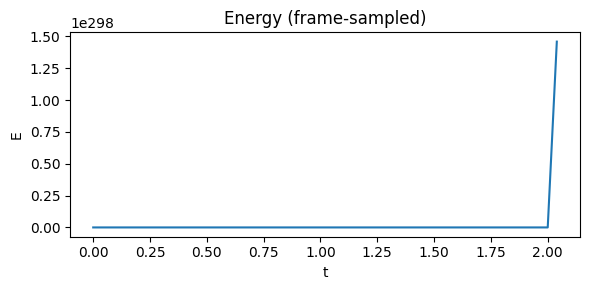

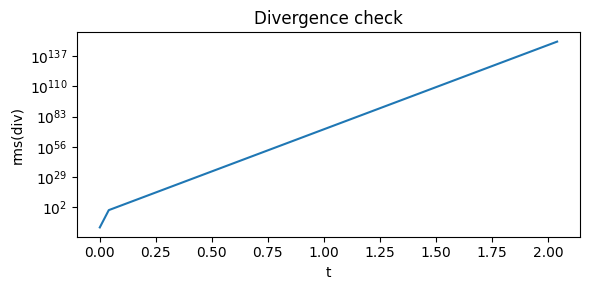

In [ ]:
# # Cell 2: Run
# GIF_PATH_MIN = "/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Code/oscillating_blob_igw_minimal.gif"

# diag = simulate_igw_minimal(
#     gif_path=GIF_PATH_MIN,
#     fps=25,
#     loop=0,
#     Lx=4.0,
#     z_bot=-4.0,
#     z_top=0.0,
#     nx=192,
#     nz=192,
#     dt=0.004,
#     tmax=12.0,
#     g=4.0,
#     rho_top=1.2,
#     rho_bottom=2.0,
#     rho_ref=1.6,
#     nu=1.0e-4,
#     kappa=1.0e-4,
#     x0=2.0,
#     z_eq=-2.5,
#     sx=0.22,
#     sz=0.18,
#     eta0=0.20,   # blob displacement amplitude
#     w_blob0=0.0, # blob initial vertical speed
#     periodic_z=True,
# )

# plt.figure(figsize=(6, 3))
# plt.plot(diag["t_frames"], diag["energy"], lw=1.5)
# plt.xlabel("t")
# plt.ylabel("E")
# plt.title("Energy (frame-sampled)")
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(6, 3))
# plt.semilogy(diag["t_frames"], np.maximum(diag["div_rms"], 1e-16), lw=1.5)
# plt.xlabel("t")
# plt.ylabel("rms(div)")
# plt.title("Divergence check")
# plt.tight_layout()
# plt.show()
